# PYTHON - Séance 4

## Partie A

### Données

In [1]:
import json
import urllib.request
from pathlib import Path

DEBUT, FIN = "2026-01-01", "2026-09-01"


def charger_taux(devise):
    """Renvoie un dictionnaire {date: taux} pour une devise (on relit le cache s'il existe)."""
    fichier = Path("cache") / f"taux_EUR_{devise}_{DEBUT}_{FIN}.json"

    if fichier.exists():
        texte = fichier.read_text(encoding="utf-8")
    else:
        url = f"https://api.frankfurter.app/{DEBUT}..{FIN}?from=EUR&to={devise}"
        requete = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(requete, timeout=10) as r:
            texte = r.read().decode("utf-8")
        fichier.parent.mkdir(exist_ok=True)
        fichier.write_text(texte, encoding="utf-8")

    data = json.loads(texte)
    resultat = {}
    for date, valeurs in data["rates"].items():
        resultat[date] = valeurs[devise]
    return resultat


taux_usd = charger_taux("USD")
dates = sorted(taux_usd)
taux = []
for d in dates:
    taux.append(taux_usd[d])

print(len(dates), "jours")

171 jours


### A.1 Les compréhensions

In [2]:
# boucle de la séance 2
variations = []
for i in range(1, len(taux)):
    variations.append(taux[i] / taux[i - 1] - 1)

# même chose en compréhension de liste
variations_comp = [taux[i] / taux[i - 1] - 1 for i in range(1, len(taux))]

print(variations == variations_comp)

True


In [3]:
# avec une condition
hausses = [v for v in variations_comp if v > 0]
print(len(hausses), "jours de hausse sur", len(variations_comp))

# la liste des taux du début, en une ligne
taux = [taux_usd[d] for d in dates]

74 jours de hausse sur 170


In [4]:
# compréhension de dictionnaire
taux_x100 = {d: round(t * 100, 2) for d, t in taux_usd.items()}
print(list(taux_x100.items())[:3])

# seulement le mois de mars
mars = {d: t for d, t in taux_usd.items() if d.startswith("2026-03")}
print(len(mars), "jours en mars")

[('2025-12-31', 117.5), ('2026-01-02', 117.21), ('2026-01-05', 116.64)]
22 jours en mars


### A.2 enumerate, zip, sorted

In [5]:
for i, t in enumerate(taux[:5]):
    print(i, t)

0 1.175
1 1.1721
2 1.1664
3 1.1707
4 1.1684


In [6]:
for d, t in zip(dates[:5], taux[:5]):
    print(d, t)

2025-12-31 1.175
2026-01-02 1.1721
2026-01-05 1.1664
2026-01-06 1.1707
2026-01-07 1.1684


In [7]:
couples = list(zip(dates, taux))

# tri sur le taux (2e élément du couple), du plus haut au plus bas
plus_hauts = sorted(couples, key=lambda c: c[1], reverse=True)
print("3 plus hauts :", plus_hauts[:3])
print("3 plus bas   :", sorted(couples, key=lambda c: c[1])[:3])

3 plus hauts : [('2026-01-28', 1.1974), ('2026-01-29', 1.1968), ('2026-01-27', 1.1929)]
3 plus bas   : [('2026-06-24', 1.134), ('2026-06-25', 1.1342), ('2026-07-28', 1.1367)]


### A.3 f-strings, lambda, map/filter

In [8]:
from datetime import datetime

dernier = taux[-1]
date_derniere = datetime.strptime(dates[-1], "%Y-%m-%d")

print(f"1 EUR = {dernier:.2f} USD")
print(f"1 EUR = {dernier:.4f} USD le {date_derniere:%d/%m/%Y}")
print(f"Variation moyenne par jour : {sum(variations) / len(variations):.3%}")

print(f"{'date':<12}{'taux':>8}")
for d, t in zip(dates[:3], taux[:3]):
    print(f"{d:<12}{t:>8.4f}")

1 EUR = 1.16 USD
1 EUR = 1.1590 USD le 01/09/2026
Variation moyenne par jour : -0.007%
date            taux
2025-12-31    1.1750
2026-01-02    1.1721
2026-01-05    1.1664


In [9]:
carre = lambda x: x ** 2
print(carre(4))

en_pourcent = list(map(lambda v: v * 100, variations))
grosses_baisses = list(filter(lambda v: v < -0.005, variations))

print(f"première variation : {en_pourcent[0]:.3f} %")
print(len(grosses_baisses), "jours avec une baisse de plus de 0,5 %")

16
première variation : -0.247 %
12 jours avec une baisse de plus de 0,5 %


## Partie B

### B.1 Première classe

In [10]:
class SerieTaux:
    """Taux de change d'une devise contre l'euro."""

    base = "EUR"                                   # attribut de classe

    def __init__(self, devise, taux_par_date):
        self.devise = devise                       # attributs d'instance
        self.taux_par_date = taux_par_date
        self.dates = sorted(taux_par_date)

    def liste_taux(self):
        return [self.taux_par_date[d] for d in self.dates]

    def moyenne(self):
        valeurs = self.liste_taux()
        return sum(valeurs) / len(valeurs)

    def variation(self):
        """Variation en % entre le premier et le dernier jour."""
        valeurs = self.liste_taux()
        return (valeurs[-1] / valeurs[0] - 1) * 100

    def variations_quotidiennes(self):
        valeurs = self.liste_taux()
        return [valeurs[i] / valeurs[i - 1] - 1 for i in range(1, len(valeurs))]

    def taux_a(self, date):
        """Taux à une date, ou dernier taux connu avant (week-end, jour férié)."""
        dates_avant = [d for d in self.dates if d <= date]
        return self.taux_par_date[dates_avant[-1]]

    def resume(self):
        valeurs = self.liste_taux()
        return (f"{self.base}/{self.devise} du {self.dates[0]} au {self.dates[-1]}\n"
                f"  moyenne   : {self.moyenne():.4f}\n"
                f"  min / max : {min(valeurs):.4f} / {max(valeurs):.4f}\n"
                f"  variation : {self.variation():+.2f} %")

In [11]:
usd = SerieTaux("USD", taux_usd)

print(usd.devise, usd.base)
print(f"{usd.moyenne():.4f}")
print(f"{usd.variation():.2f} %")
print(usd.taux_a("2026-01-01"))     # jour férié -> taux du 31/12
print(usd.resume())

USD EUR
1.1624
-1.36 %
1.175
EUR/USD du 2025-12-31 au 2026-09-01
  moyenne   : 1.1624
  min / max : 1.1340 / 1.1974
  variation : -1.36 %


### B.2 Plusieurs objets

In [12]:
gbp = SerieTaux("GBP", charger_taux("GBP"))

series = [usd, gbp]
for s in series:
    print(f"{s.devise} | moyenne {s.moyenne():.4f} | variation {s.variation():+.2f} %")

USD | moyenne 1.1624 | variation -1.36 %
GBP | moyenne 0.8640 | variation -1.84 %


In [13]:
# attribut de classe : partagé
print(usd.base, gbp.base, SerieTaux.base)

# attribut d'instance : propre à chaque objet
print(usd.devise, gbp.devise)

# si on l'affecte sur un objet, ça crée un attribut d'instance, les autres ne bougent pas
usd.base = "XXX"
print(usd.base, gbp.base, SerieTaux.base)

EUR EUR EUR
USD GBP
XXX EUR EUR


In [14]:
# piège : liste mutable en attribut de classe
class Mauvais:
    historique = []                 # une seule liste pour toutes les instances

    def __init__(self, nom):
        self.nom = nom

    def ajouter(self, x):
        self.historique.append(x)

a = Mauvais("a")
b = Mauvais("b")
a.ajouter(1.17)
print(b.historique)                 # b a aussi la valeur !


class Bon:
    def __init__(self, nom):
        self.nom = nom
        self.historique = []        # une liste par objet

    def ajouter(self, x):
        self.historique.append(x)

a = Bon("a")
b = Bon("b")
a.ajouter(1.17)
print(b.historique)

[1.17]
[]


### B.3 Les dataclasses

In [15]:
from dataclasses import dataclass, field

@dataclass
class SerieTauxDC:
    devise: str
    taux_par_date: dict
    base: str = "EUR"
    historique: list = field(default_factory=list)   # une nouvelle liste pour chaque objet

    def moyenne(self):
        valeurs = list(self.taux_par_date.values())
        return sum(valeurs) / len(valeurs)


s = SerieTauxDC("GBP", charger_taux("GBP"))
print(s.devise, s.base, f"{s.moyenne():.4f}")

# __init__, l'affichage et == sont écrits automatiquement
petite = SerieTauxDC("TEST", {"2026-01-02": 1.0})
print(petite)
print(petite == SerieTauxDC("TEST", {"2026-01-02": 1.0}))

GBP EUR 0.8640
SerieTauxDC(devise='TEST', taux_par_date={'2026-01-02': 1.0}, base='EUR', historique=[])
True


## Partie C

### C.1 Première courbe

In [16]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


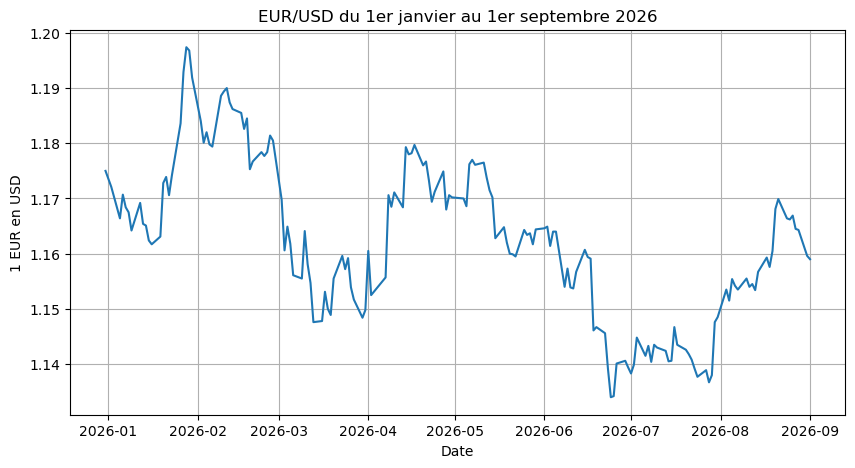

In [17]:
import matplotlib.pyplot as plt

Path("graphiques").mkdir(exist_ok=True)

dates_dt = [datetime.strptime(d, "%Y-%m-%d") for d in usd.dates]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dates_dt, usd.liste_taux())
ax.set_title("EUR/USD du 1er janvier au 1er septembre 2026")
ax.set_xlabel("Date")
ax.set_ylabel("1 EUR en USD")
ax.grid(True)

fig.savefig("graphiques/eur_usd.png", dpi=150, bbox_inches="tight")
plt.show()

### C.2 Plusieurs graphiques

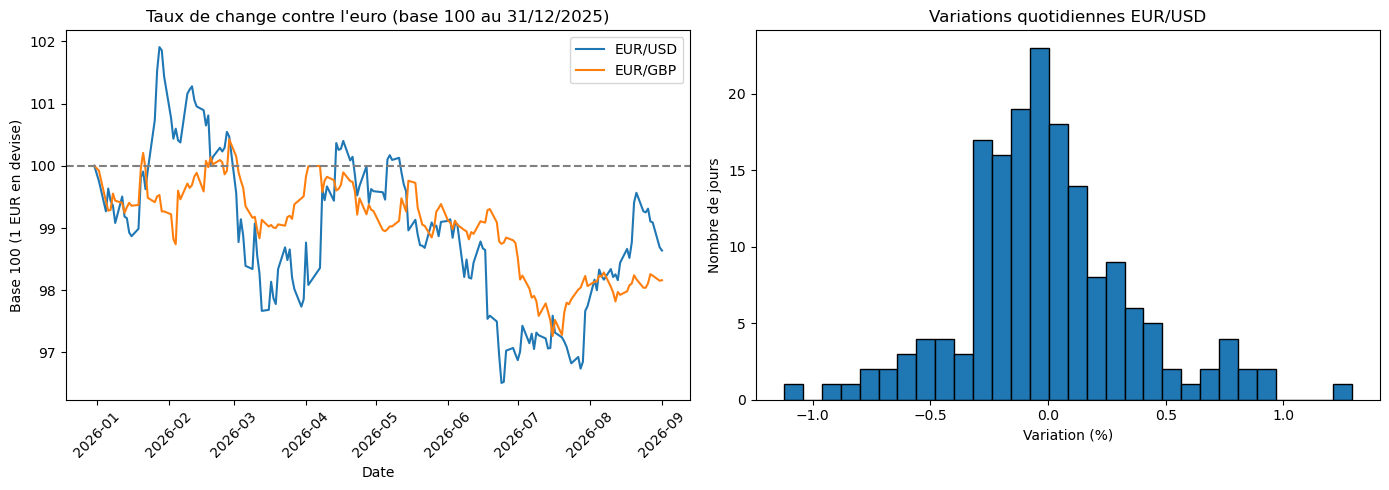

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# comparaison en base 100 (les devises n'ont pas la même échelle)
for s in series:
    valeurs = s.liste_taux()
    base100 = [v / valeurs[0] * 100 for v in valeurs]
    ax1.plot([datetime.strptime(d, "%Y-%m-%d") for d in s.dates], base100, label=f"EUR/{s.devise}")

ax1.axhline(100, linestyle="--", color="grey")
ax1.set_title("Taux de change contre l'euro (base 100 au 31/12/2025)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Base 100 (1 EUR en devise)")
ax1.legend()
ax1.tick_params(axis="x", rotation=45)

# histogramme des variations quotidiennes
var_pct = [v * 100 for v in usd.variations_quotidiennes()]
ax2.hist(var_pct, bins=30, edgecolor="black")
ax2.set_title("Variations quotidiennes EUR/USD")
ax2.set_xlabel("Variation (%)")
ax2.set_ylabel("Nombre de jours")

fig.tight_layout()
fig.savefig("graphiques/comparaison_histogramme.png", dpi=150, bbox_inches="tight")
plt.show()

## Partie D

### D.1 Modules et ligne de commande

In [19]:
Path("src").mkdir(exist_ok=True)
Path("src/__init__.py").touch()      # fichier vide -> src devient un package

In [20]:
%%writefile src/donnees.py
"""Récupération des taux de la BCE (API Frankfurter), avec cache."""
import json
import urllib.request
from pathlib import Path

DEBUT, FIN = "2026-01-01", "2026-09-01"


def charger_taux(devise, debut=DEBUT, fin=FIN):
    """Renvoie un dictionnaire {date: taux} pour une devise (on relit le cache s'il existe)."""
    fichier = Path("cache") / f"taux_EUR_{devise}_{debut}_{fin}.json"

    if fichier.exists():
        texte = fichier.read_text(encoding="utf-8")
    else:
        url = f"https://api.frankfurter.app/{debut}..{fin}?from=EUR&to={devise}"
        requete = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(requete, timeout=10) as r:
            texte = r.read().decode("utf-8")
        fichier.parent.mkdir(exist_ok=True)
        fichier.write_text(texte, encoding="utf-8")

    data = json.loads(texte)
    return {date: valeurs[devise] for date, valeurs in data["rates"].items()}

Overwriting src/donnees.py


In [21]:
%%writefile src/serie.py
"""La classe SerieTaux."""


class SerieTaux:
    """Taux de change d'une devise contre l'euro."""

    base = "EUR"

    def __init__(self, devise, taux_par_date):
        self.devise = devise
        self.taux_par_date = taux_par_date
        self.dates = sorted(taux_par_date)

    def liste_taux(self):
        return [self.taux_par_date[d] for d in self.dates]

    def moyenne(self):
        valeurs = self.liste_taux()
        return sum(valeurs) / len(valeurs)

    def variation(self):
        """Variation en % entre le premier et le dernier jour."""
        valeurs = self.liste_taux()
        return (valeurs[-1] / valeurs[0] - 1) * 100

    def variations_quotidiennes(self):
        valeurs = self.liste_taux()
        return [valeurs[i] / valeurs[i - 1] - 1 for i in range(1, len(valeurs))]

    def taux_a(self, date):
        """Taux à une date, ou dernier taux connu avant (week-end, jour férié)."""
        dates_avant = [d for d in self.dates if d <= date]
        return self.taux_par_date[dates_avant[-1]]

    def resume(self):
        valeurs = self.liste_taux()
        return (f"{self.base}/{self.devise} du {self.dates[0]} au {self.dates[-1]}\n"
                f"  moyenne   : {self.moyenne():.4f}\n"
                f"  min / max : {min(valeurs):.4f} / {max(valeurs):.4f}\n"
                f"  variation : {self.variation():+.2f} %")

Overwriting src/serie.py


In [22]:
%%writefile src/graphiques.py
"""Graphiques matplotlib, sauvegardés en PNG dans graphiques/."""
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt

DOSSIER = Path("graphiques")


def en_dates(liste):
    return [datetime.strptime(d, "%Y-%m-%d") for d in liste]


def tracer_courbe(serie):
    DOSSIER.mkdir(exist_ok=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(en_dates(serie.dates), serie.liste_taux())
    ax.set_title(f"EUR/{serie.devise}")
    ax.set_xlabel("Date")
    ax.set_ylabel(f"1 EUR en {serie.devise}")
    ax.grid(True)
    chemin = DOSSIER / f"eur_{serie.devise.lower()}.png"
    fig.savefig(chemin, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return chemin


def tracer_comparaison(series):
    DOSSIER.mkdir(exist_ok=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    for s in series:
        valeurs = s.liste_taux()
        ax.plot(en_dates(s.dates), [v / valeurs[0] * 100 for v in valeurs], label=f"EUR/{s.devise}")
    ax.axhline(100, linestyle="--", color="grey")
    ax.set_title("Taux de change contre l'euro (base 100 au 31/12/2025)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Base 100 (1 EUR en devise)")
    ax.legend()
    chemin = DOSSIER / "comparaison.png"
    fig.savefig(chemin, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return chemin


def tracer_histogramme(serie):
    DOSSIER.mkdir(exist_ok=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist([v * 100 for v in serie.variations_quotidiennes()], bins=30, edgecolor="black")
    ax.set_title(f"Variations quotidiennes EUR/{serie.devise}")
    ax.set_xlabel("Variation (%)")
    ax.set_ylabel("Nombre de jours")
    chemin = DOSSIER / f"histogramme_{serie.devise.lower()}.png"
    fig.savefig(chemin, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return chemin

Overwriting src/graphiques.py


In [23]:
%%writefile main.py
"""Outil en ligne de commande du projet : extraire, analyser, graphiques."""
import argparse

from src.donnees import charger_taux
from src.serie import SerieTaux
from src.graphiques import tracer_courbe, tracer_comparaison, tracer_histogramme


def main():
    parser = argparse.ArgumentParser(description="Taux de change de la BCE (API Frankfurter)")
    sous_commandes = parser.add_subparsers(dest="commande", required=True)

    p_extraire = sous_commandes.add_parser("extraire", help="télécharge les taux et les met en cache")
    p_extraire.add_argument("--devises", nargs="+", default=["USD"])

    p_analyser = sous_commandes.add_parser("analyser", help="moyenne, min, max et variation")
    p_analyser.add_argument("--devise", default="USD")

    p_graph = sous_commandes.add_parser("graphiques", help="trace les graphiques en PNG")
    p_graph.add_argument("--devises", nargs="+", default=["USD"])

    args = parser.parse_args()

    if args.commande == "extraire":
        for devise in args.devises:
            taux = charger_taux(devise)
            print(f"{devise} : {len(taux)} jours dans cache/")

    elif args.commande == "analyser":
        serie = SerieTaux(args.devise, charger_taux(args.devise))
        print(serie.resume())

    elif args.commande == "graphiques":
        series = [SerieTaux(d, charger_taux(d)) for d in args.devises]
        for s in series:
            print("->", tracer_courbe(s))
            print("->", tracer_histogramme(s))
        print("->", tracer_comparaison(series))


if __name__ == "__main__":
    main()

Overwriting main.py


In [24]:
!python main.py --help

usage: main.py [-h] {extraire,analyser,graphiques} ...

Taux de change de la BCE (API Frankfurter)

positional arguments:
  {extraire,analyser,graphiques}
    extraire            télécharge les taux et les met en cache
    analyser            moyenne, min, max et variation
    graphiques          trace les graphiques en PNG

options:
  -h, --help            show this help message and exit


In [25]:
!python main.py extraire --devises USD GBP

USD : 171 jours dans cache/
GBP : 171 jours dans cache/


In [26]:
!python main.py analyser --devise GBP

EUR/GBP du 2025-12-31 au 2026-09-01
  moyenne   : 0.8640
  min / max : 0.8487 / 0.8763
  variation : -1.84 %


In [27]:
!python main.py graphiques --devises USD GBP

-> graphiques/eur_usd.png
-> graphiques/histogramme_usd.png
-> graphiques/eur_gbp.png
-> graphiques/histogramme_gbp.png
-> graphiques/comparaison.png


In [28]:
# __name__ vaut "__main__" quand on lance le fichier, et le nom du module quand on l'importe
import src.donnees
print(__name__)
print(src.donnees.__name__)

__main__
src.donnees


### D.2 Rendu final

In [29]:
# requirements.txt avec les versions installées
from importlib.metadata import version

paquets = ["pandas", "numpy", "polars", "matplotlib", "seaborn"]

with open("requirements.txt", "w") as f:
    for p in paquets:
        f.write(f"{p}=={version(p)}\n")

print(Path("requirements.txt").read_text())

pandas==2.2.2
numpy==1.26.4
polars==1.44.2
matplotlib==3.9.2
seaborn==0.13.2



In [30]:
%%writefile .gitignore
__pycache__/
.ipynb_checkpoints/
*.log
.DS_Store
.venv/

Overwriting .gitignore


In [31]:
%%writefile README.md
# Cours Python - BFA1

Récupération et analyse des taux de change de référence de la BCE (API Frankfurter) du 1er janvier au 1er septembre 2026, pour le dollar (USD) et la livre sterling (GBP).

Membres du groupe : Maxime, Sacha, Gabriel

Projet de groupe, Magistère BFA1, 2026-2027.

## Installation

Python 3.11 ou plus récent.

```bash
git clone https://github.com/gturk695-boop/Test.git
cd Test
pip install -r requirements.txt
```

## Utilisation

```bash
python main.py --help
python main.py extraire --devises USD GBP          # télécharge les taux dans cache/
python main.py analyser --devise USD               # moyenne, min, max, variation
python main.py graphiques --devises USD GBP        # PNG dans graphiques/
```

Exemple de sortie de `python main.py analyser --devise USD`

```
EUR/USD du 2025-12-31 au 2026-09-01
  moyenne   : 1.1624
  min / max : 1.1340 / 1.1974
  variation : -1.36 %
```

## Documents

| Séance | Code | Réponses aux questions |
|---|---|---|
| Séance 1 | [Séance_1_Notebook.ipynb](S%C3%A9ance_1_Notebook.ipynb) | [Séance_1 - questions](S%C3%A9ance_1%20-%20questions.md) |
| Séance 2 | [Séance_2_Notebook.ipynb](S%C3%A9ance_2_Notebook.ipynb) | [Séance_2 - questions](S%C3%A9ance_2%20-%20questions.md) |
| Séance 3 | [Séance_3_Notebook.ipynb](S%C3%A9ance_3_Notebook.ipynb) | [Séance_3 - questions](S%C3%A9ance_3%20-%20questions.md) |
| Séance 4 | [Séance_4_Notebook.ipynb](S%C3%A9ance_4_Notebook.ipynb) | [Séance_4 - questions](S%C3%A9ance_4%20-%20questions.md) |

**[Rapport final](S%C3%A9ance_4%20-%20Rapport%20Final.md)**

Overwriting README.md
